# SOC-50 → 28클래스 재그룹 분류기 학습

## 이 노트북의 목적
기존 분류기는 **50종(type 레벨)** 을 그대로 맞혀서 fine-grained 난이도가 매우 높다.
세분류를 **덜 세분화(28클래스)** 해서 분류 난이도를 낮추고 성능을 끌어올린다.

## 재그룹 규칙
- **민수 차량 40종 → 18클래스** (type → 서브클래스로 묶음)
  - Car 5 / Truck 9 / Bus 3 / **Construction 1(신설)**
- **MSTAR 군용 10종 → 그대로 10클래스** (군용은 묶지 않음)
- **합계: 18 + 10 = 28클래스**

## 커스텀 처리 (Special 클래스 해체)
- 구급차(JINBEI_SY5033XJH) + ECV(Lveco_Proud_2009) → **Small_Bus**에 흡수 (크기 유사)
- 로더(SDLG_ZL40F) + 롤러(Changlin_8228-5) → **Construction** 신설
  (D7 불도저와 의미는 같지만 D7은 MSTAR라 출처 혼합 방지 위해 별도)

## 동작 방식
ImageFolder의 폴더(=50종 type)를 그대로 두고, **라벨만 28클래스로 매핑**한다.
디스크 폴더를 복사·재구성하지 않으므로 빠르고 되돌리기 쉽다.

## 준비물 (드라이브 `MyDrive/ATRNet-STAR/`)
- `soc50.tar` (SOC-50 칩)
- 런타임 → T4 GPU

## 1. 환경 + 데이터 준비

In [ ]:
import torch, os
from google.colab import drive
drive.mount('/content/drive')

SAVE_DIR = "/content/drive/MyDrive/ATRNet-STAR"
DATA_DIR = "/content/SOC_50classes"
if not os.path.exists(DATA_DIR):
    !cp "{SAVE_DIR}/soc50.tar" /content/soc50.tar
    !tar -xf /content/soc50.tar -C /content/ && rm /content/soc50.tar

TRAIN_DIR = os.path.join(DATA_DIR, "train")
TEST_DIR  = os.path.join(DATA_DIR, "test")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)
print("train 폴더(=50종) 수:", len(os.listdir(TRAIN_DIR)))

Mounted at /content/drive
device: cuda
train 폴더(=50종) 수: 50


## 2. 50종 → 28클래스 매핑 정의

`TYPE2GROUP` 딕셔너리가 **50개 type 폴더명 → 28개 그룹명**을 정의한다.
- 민수 18 + MSTAR 10 = 28
- 폴더명은 SOC-50 데이터의 실제 클래스 폴더명과 정확히 일치해야 함 (오타·공백 주의)

> ⚠ 만약 매핑 누락(폴더명 불일치)이 있으면 아래 셀의 검증에서 에러로 알려준다.

In [ ]:
# ===== 50종 type → 28 group 매핑 =====
TYPE2GROUP = {
    # --- Car (5) ---
    "Hawtai_EV160B": "Mini_Car",        "Chery_qq3": "Mini_Car",
    "Chery_Arrizo 5": "Medium_Car",     "Buick_Excelle_GT": "Medium_Car",
    "Great_Wall_Voleex_C50": "Large_Car","Hongqi_CA7180A3E": "Large_Car", "Hongqi_h5": "Large_Car",
    "Lincoln_MKC": "Compact_SUV",       "Mitsubishi_Outlander_2003": "Compact_SUV", "Jeep_Patriot": "Compact_SUV",
    "Changfeng_Cheetah_CFA6473C": "Medium_SUV", "Chang'an_CS75_Plus": "Medium_SUV", "Chevrolet_Blazer_1998": "Medium_SUV",
    # --- Truck (9) ---
    "FAW_Jiabao_T51": "Light_DT",       "Foton_BJ1045V9JB5-54": "Light_DT", "WAW_Aochi_1800": "Light_DT",
    "Dongfeng_Tianjin_DFH2200B": "Heavy_DT",
    "SHACMAN_DeLong_X3000": "Heavy_ST", "Dongfeng_Tianjin_KR230": "Heavy_ST",
    "SHACMAN_DeLong_M3000": "Heavy_FT", "FAW_J6P": "Heavy_FT",
    "WAW_Aochi_Hongrui": "Medium_TT",   "Dongfeng_Duolika": "Medium_TT",
    "JAC_Junling": "Light_PV",
    "Huanghai_N1": "Pickup",            "Great_Wall_poer": "Pickup",
    "CNHTC_HOWO": "Mixer_Truck",
    "Hyundai_HLF25_II": "Forklift",
    # --- Bus (3) — 구급차·ECV는 Small_Bus로 흡수 ---
    "Dongfeng_Forthing_Lingzhi": "Small_Bus", "Buick_GL8": "Small_Bus",
    "Wuling_Rongguang_V": "Small_Bus",  "Chang'an_Starlight_4500": "Small_Bus",
    "JINBEI_SY5033XJH": "Small_Bus",    "Lveco_Proud_2009": "Small_Bus",   # 구급차, ECV
    "Dongfeng_EQ6608LTV": "Medium_Bus", "MAXUS_V80": "Medium_Bus", "Yangzi_YZK6590XCA": "Medium_Bus",
    "Yutong_ZK6120HY1": "Large_Bus",
    # --- Construction (1, 신설) — 로더+롤러 ---
    "SDLG_ZL40F": "Construction",       "Changlin_8228-5": "Construction",
    # --- MSTAR 군용 (10) — type 그대로 ---
    "2S1": "2S1", "BMP2": "BMP2", "BRDM_2": "BRDM_2", "BTR_60": "BTR_60", "BTR70": "BTR70",
    "D7": "D7", "T62": "T62", "T72": "T72", "ZIL131": "ZIL131", "ZSU_23_4": "ZSU_23_4",
}

# ----- 검증: 디스크 폴더와 매핑 키가 일치하는지 -----
disk_types = set(os.listdir(TRAIN_DIR))
map_types  = set(TYPE2GROUP)
missing = disk_types - map_types     # 폴더엔 있는데 매핑에 없음
extra   = map_types - disk_types     # 매핑에만 있고 폴더엔 없음
print("폴더 종류:", len(disk_types), "/ 매핑 종류:", len(map_types))
if missing: print("⚠ 매핑 누락(폴더에 있음):", sorted(missing))
if extra:   print("⚠ 폴더명 불일치(매핑에만 있음):", sorted(extra))
if not missing and not extra: print("✓ 매핑 완전 일치")

GROUPS = sorted(set(TYPE2GROUP.values()))
print(f"\n최종 그룹 수: {len(GROUPS)}")
print(GROUPS)

폴더 종류: 50 / 매핑 종류: 50
✓ 매핑 완전 일치

최종 그룹 수: 28
['2S1', 'BMP2', 'BRDM_2', 'BTR70', 'BTR_60', 'Compact_SUV', 'Construction', 'D7', 'Forklift', 'Heavy_DT', 'Heavy_FT', 'Heavy_ST', 'Large_Bus', 'Large_Car', 'Light_DT', 'Light_PV', 'Medium_Bus', 'Medium_Car', 'Medium_SUV', 'Medium_TT', 'Mini_Car', 'Mixer_Truck', 'Pickup', 'Small_Bus', 'T62', 'T72', 'ZIL131', 'ZSU_23_4']


## 3. 라벨 매핑 데이터셋

`ImageFolder`는 폴더명 알파벳순으로 0~49 라벨을 매기는데, 그 라벨을 **28그룹 인덱스로 다시 매핑**한다.
- `GROUP2IDX`: 28그룹 → 0~27 정수 (알파벳순 고정 — 추론 시 동일 순서 필수)
- `remap`: ImageFolder의 50종 라벨 → 28그룹 라벨로 변환하는 타깃 변환

> 폴더를 복사하지 않고 라벨만 바꾸므로, 같은 디스크 데이터로 50종/28그룹 학습을 모두 할 수 있다.

In [ ]:
import torchvision.transforms as T
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

GROUP2IDX = {g: i for i, g in enumerate(GROUPS)}      # 28그룹 → 0~27
NUM_CLASSES = len(GROUPS)

# 증강 레시피 = 기존 분류기와 동일 (공정 비교)
train_transform = T.Compose([
    T.Resize((128, 128)),
    T.Grayscale(num_output_channels=3),
    T.RandomHorizontalFlip(),
    T.RandomAffine(degrees=10, translate=(0.1, 0.1)),
    T.ToTensor(),
    T.RandomErasing(p=0.3),
])
test_transform = T.Compose([
    T.Resize((128, 128)),
    T.Grayscale(num_output_channels=3),
    T.ToTensor(),
])

def make_remapped(root, transform):
    ds = ImageFolder(root, transform=transform)
    # ImageFolder 라벨(50종 인덱스) → 28그룹 인덱스 변환표
    idx2group = {i: GROUP2IDX[TYPE2GROUP[name]] for i, name in enumerate(ds.classes)}
    # ⚠ 이중 매핑 금지: samples만 변환하고 target_transform은 None
    ds.samples = [(p, idx2group[y]) for p, y in ds.samples]
    ds.targets = [y for _, y in ds.samples]
    ds.imgs = ds.samples            # 일부 torchvision 버전 호환
    ds.target_transform = None      # 핵심: __getitem__에서 재매핑 안 되도록
    return ds

train_ds = make_remapped(TRAIN_DIR, train_transform)
test_ds  = make_remapped(TEST_DIR,  test_transform)
train_loader = DataLoader(train_ds, batch_size=64, shuffle=True,  num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=64, shuffle=False, num_workers=2, pin_memory=True)
print(f"train {len(train_ds)} / test {len(test_ds)} / 클래스 {NUM_CLASSES}")

# 그룹별 샘플 수 분포 (불균형 확인)
from collections import Counter
cnt = Counter(train_ds.targets)
print("\n그룹별 train 샘플 수:")
for g in GROUPS:
    print(f"  {g:15s}: {cnt[GROUP2IDX[g]]}")

train 18071 / test 17603 / 클래스 28

그룹별 train 샘플 수:
  2S1            : 299
  BMP2           : 698
  BRDM_2         : 298
  BTR70          : 233
  BTR_60         : 256
  Compact_SUV    : 1080
  Construction   : 720
  D7             : 299
  Forklift       : 360
  Heavy_DT       : 360
  Heavy_FT       : 720
  Heavy_ST       : 720
  Large_Bus      : 360
  Large_Car      : 1080
  Light_DT       : 1080
  Light_PV       : 360
  Medium_Bus     : 1080
  Medium_Car     : 720
  Medium_SUV     : 1080
  Medium_TT      : 720
  Mini_Car       : 720
  Mixer_Truck    : 360
  Pickup         : 720
  Small_Bus      : 2160
  T62            : 299
  T72            : 691
  ZIL131         : 299
  ZSU_23_4       : 299


## 4. 모델 — ConvNeXt-Tiny (28클래스 출력)

기존 ConvNeXt 분류기와 동일 구조/레시피, **출력층만 28로** 교체.
- ImageNet 사전학습 → classifier[2]만 28클래스로
- label smoothing 0.1, AdamW 1e-4, cosine 30에폭

> 다른 백본(ResNet18/SARATR-X)으로 바꾸려면 이 셀만 교체.

In [ ]:
import torch.nn as nn
from torchvision.models import convnext_tiny, ConvNeXt_Tiny_Weights

MODEL_NAME = "convnext_soc28"
EPOCHS, LR = 30, 1e-4

model = convnext_tiny(weights=ConvNeXt_Tiny_Weights.DEFAULT)
model.classifier[2] = nn.Linear(model.classifier[2].in_features, NUM_CLASSES)
model = model.to(device)

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

CKPT_PATH = f"{SAVE_DIR}/checkpoints/{MODEL_NAME}_ckpt.pth"
os.makedirs(f"{SAVE_DIR}/checkpoints", exist_ok=True)
print(f"{MODEL_NAME} / 출력 {NUM_CLASSES}클래스")

Downloading: "https://download.pytorch.org/models/convnext_tiny-983f1562.pth" to /root/.cache/torch/hub/checkpoints/convnext_tiny-983f1562.pth


100%|██████████| 109M/109M [00:00<00:00, 146MB/s] 


convnext_soc28 / 출력 28클래스


## 5. 학습 루프 (체크포인트 이어학습)

In [ ]:
import time
start_epoch, history = 0, []
if os.path.exists(CKPT_PATH):
    c = torch.load(CKPT_PATH, map_location=device, weights_only=False)
    model.load_state_dict(c["model"]); optimizer.load_state_dict(c["optimizer"])
    scheduler.load_state_dict(c["scheduler"])
    start_epoch, history = c["epoch"] + 1, c["history"]
    print(f"체크포인트 발견 → 에폭 {start_epoch+1}부터 재개")

for epoch in range(start_epoch, EPOCHS):
    model.train(); tl = correct = n = 0
    t0 = time.time()
    for x, y in train_loader:
        x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
        optimizer.zero_grad()
        out = model(x); loss = criterion(out, y)
        loss.backward(); optimizer.step()
        tl += loss.item()*len(y); correct += (out.argmax(1)==y).sum().item(); n += len(y)
    scheduler.step()
    history.append({"epoch": epoch, "train_loss": tl/n, "train_acc": correct/n})
    print(f"Epoch {epoch+1}/{EPOCHS}  loss {tl/n:.3f}  train_acc {correct/n:.3f}  ({time.time()-t0:.0f}s)")
    torch.save({"model": model.state_dict(), "optimizer": optimizer.state_dict(),
                "scheduler": scheduler.state_dict(), "epoch": epoch, "history": history}, CKPT_PATH)
print("학습 완료")

Epoch 1/30  loss 2.297  train_acc 0.348  (115s)
Epoch 2/30  loss 1.694  train_acc 0.575  (109s)
Epoch 3/30  loss 1.465  train_acc 0.667  (110s)
Epoch 4/30  loss 1.317  train_acc 0.731  (109s)
Epoch 5/30  loss 1.199  train_acc 0.782  (110s)
Epoch 6/30  loss 1.126  train_acc 0.812  (110s)
Epoch 7/30  loss 1.063  train_acc 0.836  (109s)
Epoch 8/30  loss 1.006  train_acc 0.860  (109s)
Epoch 9/30  loss 0.974  train_acc 0.875  (110s)
Epoch 10/30  loss 0.925  train_acc 0.896  (110s)
Epoch 11/30  loss 0.906  train_acc 0.902  (110s)
Epoch 12/30  loss 0.875  train_acc 0.915  (110s)
Epoch 13/30  loss 0.868  train_acc 0.919  (109s)
Epoch 14/30  loss 0.844  train_acc 0.928  (109s)
Epoch 15/30  loss 0.832  train_acc 0.930  (109s)
Epoch 16/30  loss 0.812  train_acc 0.939  (109s)
Epoch 17/30  loss 0.811  train_acc 0.940  (109s)
Epoch 18/30  loss 0.797  train_acc 0.944  (109s)
Epoch 19/30  loss 0.784  train_acc 0.949  (109s)
Epoch 20/30  loss 0.777  train_acc 0.953  (109s)
Epoch 21/30  loss 0.774  trai

## 6. 평가 + 저장

- 전체 정확도(OA) 측정
- **혼동행렬**로 어느 그룹끼리 헷갈리는지 확인 (28클래스라 50종보다 읽기 쉬움)
- 추론용 가중치 `*_final.pth` + 클래스 순서 json 저장 (파이프라인에서 사용)

In [ ]:
import json, numpy as np
model.eval(); y_true, y_pred = [], []
with torch.no_grad():
    for x, y in test_loader:
        out = model(x.to(device, non_blocking=True))
        y_pred.extend(out.argmax(1).cpu().tolist()); y_true.extend(y.tolist())
y_true, y_pred = np.array(y_true), np.array(y_pred)
oa = float((y_true==y_pred).mean())
print(f"Overall Accuracy (28클래스): {oa*100:.2f}%")
print("(참고: 기존 50종 ConvNeXt 87.75% — 클래스 줄여 더 높게 기대)")

per_class = {g: float((y_pred[y_true==i]==i).mean()) for i,g in enumerate(GROUPS) if (y_true==i).sum()>0}
print("\n그룹별 정확도 (낮은 순 Top10 — 어려운 그룹):")
for g,a in sorted(per_class.items(), key=lambda x:x[1])[:10]:
    print(f"  {g:15s}: {a*100:.1f}%")

# 가중치 + 클래스 순서 저장
torch.save(model.state_dict(), f"{SAVE_DIR}/checkpoints/{MODEL_NAME}_final.pth")
os.makedirs(f"{SAVE_DIR}/results", exist_ok=True)
with open(f"{SAVE_DIR}/results/{MODEL_NAME}.json","w") as f:
    json.dump({"model": MODEL_NAME, "num_classes": NUM_CLASSES, "classes": GROUPS,
               "type2group": TYPE2GROUP, "overall_acc": oa,
               "per_class_acc": per_class, "history": history}, f, ensure_ascii=False)
print(f"\n저장: checkpoints/{MODEL_NAME}_final.pth + results/{MODEL_NAME}.json")

Overall Accuracy (28클래스): 90.86%
(참고: 기존 50종 ConvNeXt 87.75% — 클래스 줄여 더 높게 기대)

그룹별 정확도 (낮은 순 Top10 — 어려운 그룹):
  Medium_Car     : 73.8%
  Compact_SUV    : 79.9%
  Medium_SUV     : 83.0%
  Large_Car      : 84.4%
  Mini_Car       : 87.4%
  Small_Bus      : 88.2%
  Light_PV       : 89.2%
  Pickup         : 89.9%
  Medium_Bus     : 90.4%
  Medium_TT      : 91.9%

저장: checkpoints/convnext_soc28_final.pth + results/convnext_soc28.json


## 7. 혼동행렬 시각화

/tmp/ipykernel_574/270998983.py:10: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing from font(s) DejaVu Sans.
  fig.colorbar(im, shrink=0.7); plt.tight_layout(); plt.show()
/tmp/ipykernel_574/270998983.py:10: UserWarning: Glyph 52769 (\N{HANGUL SYLLABLE CEUG}) missing from font(s) DejaVu Sans.
  fig.colorbar(im, shrink=0.7); plt.tight_layout(); plt.show()
/tmp/ipykernel_574/270998983.py:10: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  fig.colorbar(im, shrink=0.7); plt.tight_layout(); plt.show()
/tmp/ipykernel_574/270998983.py:10: UserWarning: Glyph 45813 (\N{HANGUL SYLLABLE DAB}) missing from font(s) DejaVu Sans.
  fig.colorbar(im, shrink=0.7); plt.tight_layout(); plt.show()
/tmp/ipykernel_574/270998983.py:10: UserWarning: Glyph 54844 (\N{HANGUL SYLLABLE HON}) missing from font(s) DejaVu Sans.
  fig.colorbar(im, shrink=0.7); plt.tight_layout(); plt.show()
/tmp/ipykernel_574/270998983.py:10: UserWarning: Glyph 46041 (\N{HANGUL SYLLAB

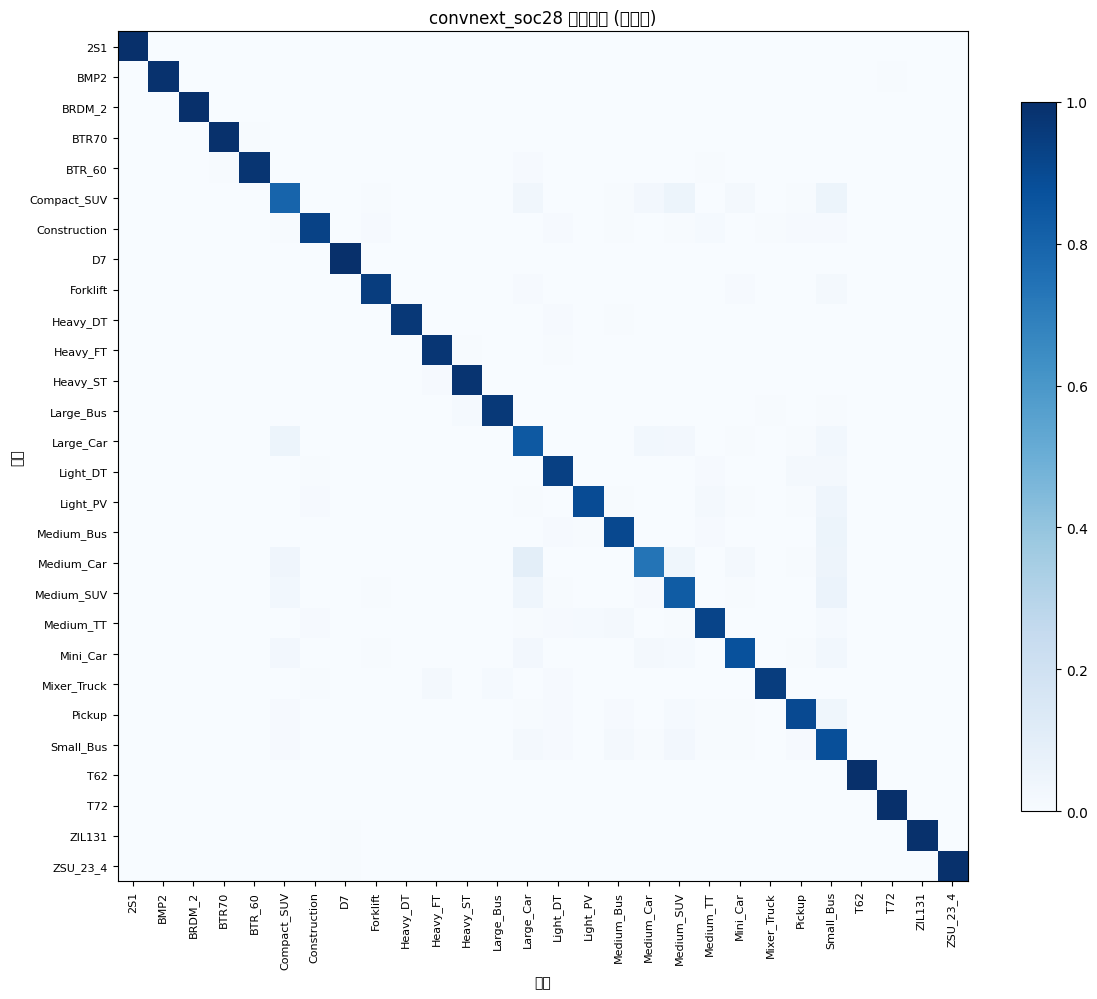

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred, normalize="true")
fig, ax = plt.subplots(figsize=(12, 11))
im = ax.imshow(cm, cmap="Blues", vmin=0, vmax=1)
ax.set_xticks(range(NUM_CLASSES)); ax.set_xticklabels(GROUPS, rotation=90, fontsize=8)
ax.set_yticks(range(NUM_CLASSES)); ax.set_yticklabels(GROUPS, fontsize=8)
ax.set_xlabel("예측"); ax.set_ylabel("정답"); ax.set_title(f"{MODEL_NAME} 혼동행렬 (정규화)")
fig.colorbar(im, shrink=0.7); plt.tight_layout(); plt.show()

## 다음 단계 — 파이프라인에서 사용하기

`pipeline/soc28/dom48_convnext.ipynb`의 분류기 로드 셀에서:
1. 모델을 `convnext_tiny()` + `classifier[2] = nn.Linear(..., 28)`로 만들고
2. `checkpoints/convnext_soc28_final.pth` 로드
3. **클래스 순서**는 `results/convnext_soc28.json`의 `classes`(=GROUPS) 사용

⚠ **GT 라벨도 28그룹으로 변환** 필요: DOM XML의 `type`을 `TYPE2GROUP`으로 매핑해서 채점해야
분류기 출력(28그룹)과 정답이 같은 체계가 됨. (50종 GT를 그대로 쓰면 전부 불일치)

### 비교 포인트 (보고서)
- 50종 87.75% vs 28그룹 OA → 세분화 완화의 효과
- 단, **fine-grained 식별 능력은 포기**하는 트레이드오프 (예: 같은 SUV 3종을 한 클래스로)
  → 군 정찰 목적상 "차종 대분류"로 충분한지 vs "정확한 기종 식별"이 필요한지에 따라 선택